# Exercise 1: Profile Data

**Aim:** To work with vertical profile data and make some standard calculations.

**Required Outputs:**
Four figures should be generated (replace YourName with your actual last name):
- ex1fig1-YourName-Messfern.png: Showing the temperature and practical salinity
- ex1fig2-YourName-Messfern.png: Showing the conservative temperature and absolute salinity profiles
- ex1fig3-YourName-Messfern.png: Showing a basic TS profile
- ex1fig4-YourName-Messfern.png: Showing a TS profile focused on waters denser than 27.

**Fixed File Paths (DO NOT CHANGE):**
- NetCDF files: `./data/MSM121_054_1db.nc` and `./data/MSM121_054_1db_edited.nc`
- Figures directory: `./figures/`

---

**Complete your information here:**

- **Your Name:** [Yannis Mo Mako]
- **Date:** [15.05.2026]
- **Student ID:** [7850836]

**Replace the placeholder text above with your actual information.**

## Importing Required Packages

In [10]:
# Importing required packages here
import matplotlib.pyplot as plt
import gsw 
import numpy as np
import xarray as xr
import os

from matplotlib.ticker import ScalarFormatter

# Import seasenselib for CTD data processing
from seasenselib.readers import SbeCnvReader, NetCdfReader
from seasenselib.writers import NetCdfWriter

## File Paths Setup

In [11]:
# Input file paths hLLO
cnv_file_with_path = '../data/MSM121_054_1db.cnv'

# Output file paths for netCDF (DO NOT CHANGE THESE)
netcdf_file_with_path = '../data/MSM121_054_1db.nc'
netcdf_file_with_path_edited = '../data/MSM121_054_1db_edited.nc'

# YOUR CODE HERE
# Set up the figures directory - DO NOT CHANGE THIS PATH
# The autograder expects figures to be saved in '../figures/'
figdir = '../figures/'


# Create figures directory if it doesn't exist
if not os.path.exists(figdir):
    os.makedirs(figdir)
    
print(f"Figures will be saved to: {figdir}")
print(f"Data file: {cnv_file_with_path}")

Figures will be saved to: ../figures/
Data file: ../data/MSM121_054_1db.cnv


In [5]:
# Test that setup is complete
assert 'figdir' in locals(), "figdir variable not defined"
assert figdir.endswith('/'), "figdir should end with '/'"
# Note: CNV file will be downloaded automatically when needed, so we don't test for existence here
print("✓ File setup test passed!")

✓ File setup test passed!


## Transforming to xarray

### Convert CNV file to netCDF

In [12]:
# Using seasenselib for CTD data processing
# Data from Seabird sensors typically come in as .cnv files.  
# These files can be converted to netCDF format using the seasenselib package.

# YOUR CODE HERE
# Using seasenselib:   
# Read CTD data from CNV file using SbeCnvReader
# Get the dataset using reader.get_data()
# Name the dataset ctd_data

reader = SbeCnvReader(cnv_file_with_path)

# Get dataset
ctd_data = reader.get_data()

# Print dataset
#print(ctd_data)


INFO:seasenselib.readers.base:Initialized reader SbeCnvReader for '../data/MSM121_054_1db.cnv'
/tmp/ipykernel_13016/3719881658.py:14: DeprecationWarning: get_data() is deprecated and will be removed in version 1.0.0. Use the 'data' property instead: reader.data
  ctd_data = reader.get_data()
INFO:seasenselib.readers.base:Loading data from '../data/MSM121_054_1db.cnv'
INFO:pycnv: Opening file: ../data/MSM121_054_1db.cnv
INFO:pycnv:Dates computed based on timeS


Computing date


INFO:seasenselib.pipeline.pipeline:Starting pipeline with 7 stages
INFO:seasenselib.pipeline.mapping.handlers.mapping_runner:Mapped 8 variables
INFO:seasenselib.pipeline.derivation.handlers.derivation_runner:Derived 8 parameter(s)
INFO:seasenselib.pipeline.metadata_extraction.handlers.extraction_runner:Extracted metadata from 2 source(s)
INFO:seasenselib.pipeline.metadata_enrichment.handlers.cf_convention:Applied CF-1.13 conventions
INFO:seasenselib.pipeline.metadata_enrichment.handlers.acdd_convention:Applied ACDD conventions
INFO:seasenselib.pipeline.pipeline:Pipeline completed successfully


### Write to netCDF


In [14]:
# If there are problems with saving because of attributes, then uncomment this line
#ctd_data = ctd_data.drop_attrs()
#
# Write dataset with CTD data to netCDF file using NetCdfWriter
# Only write if the file doesn't already exist
if not os.path.exists(netcdf_file_with_path):
    writer = NetCdfWriter(ctd_data)
    writer.write(netcdf_file_with_path)

print(f"NetCDF conversion complete: {netcdf_file_with_path}")

INFO:seasenselib.writers.base:Initialized writer NetCdfWriter
INFO:seasenselib.writers.netcdf_writer:Writing netCDF file to '../data/MSM121_054_1db.nc'
INFO:seasenselib.writers.netcdf_writer:Wrote netCDF file to '../data/MSM121_054_1db.nc'


NetCDF conversion complete: ../data/MSM121_054_1db.nc


In [15]:
# Test that conversion worked
assert os.path.exists(netcdf_file_with_path), "NetCDF file was not created"
print("✓ CNV to NetCDF conversion test passed!")

✓ CNV to NetCDF conversion test passed!


### Open file and show contents

In [16]:
# YOUR CODE HERE
# load data using xr.open_dataset()
ctd_ds = xr.open_dataset(netcdf_file_with_path)

# print data
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 632kB
Dimensions:                     (time: 3593)
Coordinates:
  * time                        (time) datetime64[ns] 29kB 2000-01-01T12:28:3...
    latitude                    (time) float64 29kB ...
    longitude                   (time) float64 29kB ...
Data variables: (12/19)
    absolute_salinity           (time) float64 29kB ...
    conductivity_1              (time) float64 29kB ...
    conductivity_2              (time) float64 29kB ...
    conservative_temperature_1  (time) float64 29kB ...
    conservative_temperature_2  (time) float64 29kB ...
    density                     (time) float64 29kB ...
    ...                          ...
    salinity                    (time) float64 29kB ...
    speed_of_sound              (time) float64 29kB ...
    temperature_1               (time) float64 29kB ...
    temperature_2               (time) float64 29kB ...
    timeQ                       (time) float64 29kB ...
    timeS    

In [17]:
# Test that data loaded correctly
assert 'ctd_ds' in locals(), "ctd_ds variable not found"
assert hasattr(ctd_ds, 'data_vars'), "ctd_ds should be an xarray Dataset"
print("✓ Data loading test passed!")

✓ Data loading test passed!


## Understanding the data format

The data stored within the netcdf file include measured parameters as `variables`, for example:

- `pressure` is pressure in decibars
- `temperature` is temperature in degrees Celcius
- `salinity` is salinity from the secondary sensor
- `latitude` is the position where the data were take from in degrees North (positive) or south (negative)
- `longitude` is the longitude with degrees east (positive) or west (negative)

The list of `Attributes` include details like the single value for latitude/longitude, or the date the file was created.

In [22]:
# Here we are defining the names of the variables in the netCDF file
# If your netcdf file calls salinity "PSAL", you would change the sal_string to 'PSAL'
sal_string = 'salinity'
temp_string = 'temperature_1'
pres_string = 'pressure'
lon_string = 'longitude'
lat_string = 'latitude'
SA_string = 'absolute_salinity'
CT_string = 'conservative_temperature'
# You could also define these pairs in a dictionary (https://www.w3schools.com/python/python_dictionaries.asp)

# Plot the temperature and salinity

To plot in Python, we often use the package `matplotlib` which you've imported above. This includes a variety of functions which can be used to generate figures in python.

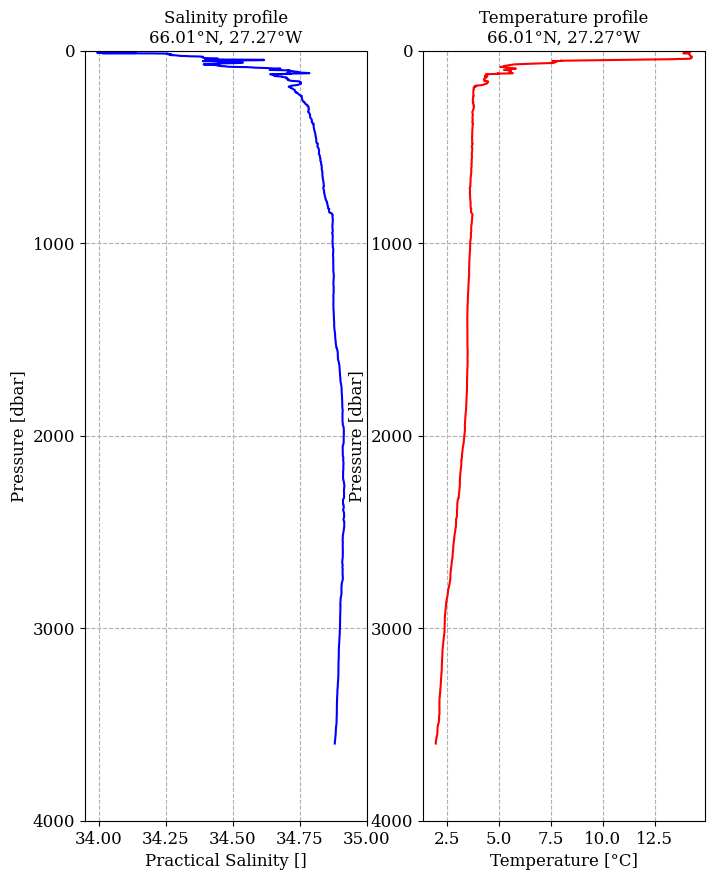

In [25]:
# To initialise a figure, use matplotlib.plt.figure() which takes inputs within the brackets
# Since matplotlib is long to write, in the import cell above, we've imported it as plt

plt.rcParams['font.family'] = 'serif'

plt.figure(1, figsize=(8, 10)) 

# In case the figure 1 already exists, clear it using clf()
plt.clf()

# Within the figure window, we'll actually have two separate sets of axes.  These are called 'subplots' in matplotlib
# We'll have two subplots, one next to the other, so we'll have a 1x2 grid of subplots
plt.subplot(1,2,1)

# To plot salinity, we need to reference the salinity variable in the dataset.  This is done using the syntax ctd_ds['PSAL2']
# Here, ctd_ds is the name of the dataset, and 'PSAL2' is the name of the variable.  The variable name is case sensitive.
plt.plot(ctd_ds[sal_string], ctd_ds[pres_string], color='blue')

# Now we'd like to annotate our figure.  We can do this using the plt.xlabel() and plt.ylabel() functions
# These functions take a string as an argument, which is the text that will be displayed on the x and y axes
# An optional second argument can be used to specify the fontsize.  IMPORTANT: choose values to make the text readable.
plt.xlabel('Practical Salinity []', fontsize=12)
plt.ylabel('Pressure [dbar]', fontsize=12)

# Since pressure decreases with depth, we want to invert the y-axis so that the surface is at the top of the plot
plt.gca().invert_yaxis()
plt.ylim(ctd_ds[pres_string].max(), 0)

# Here we specify where exactly the x-ticks should be placed.  We want them at 34, 34.5, and 35
x_ticks = [34, 34.25, 34.5, 34.75, 35]
plt.xticks(x_ticks, fontsize=12)

# We don't specify for the y-axis, but we do want the text size to be readable.
plt.yticks(np.arange(0, 4001, 1000), fontsize=12)

# Finally, we can add a title to the plot using plt.title().  This function also takes a string as an argument.
plt.title('Salinity profile\n66.01°N, 27.27°W', fontsize=12)

# Add dashed gridlines
plt.grid(True, linestyle='--')

# YOUR TURN: Now, let's plot the temperature profile on the right-hand side of the figure
plt.subplot(1,2,2)

# Complete the temperature plot following the same pattern as the salinity plot
# Plot temperature vs pressure, add labels, title, formatting
# Remember to invert the y-axis and add grid
plt.plot(ctd_ds[temp_string], ctd_ds[pres_string], color='red')

plt.xlabel('Temperature [°C]', fontsize=12)
plt.ylabel('Pressure [dbar]', fontsize=12)

plt.gca().invert_yaxis()
plt.ylim(ctd_ds[pres_string].max(), 0)

plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 4001, 1000), fontsize=12)

plt.title('Temperature profile\n66.01°N, 27.27°W', fontsize=12)

plt.grid(True, linestyle='--')

# This code saves the figure to a file.  The file type is determined by the extension of the filename.
# IMPORTANT: Change YourName to your actual last name
plt.savefig(figdir + 'ex1fig1-Mako-Messfern.png')

plt.show()

In [26]:
# Test that Figure 1 was created correctly
import glob
fig1_files = glob.glob(figdir + 'ex1fig1-*-Messfern.png')
assert len(fig1_files) > 0, "Figure 1 (ex1fig1-YourName-Messfern.png) was not created"
for fig_file in fig1_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 1 test passed: {fig1_files[0]}")

✓ Figure 1 test passed: ../figures/ex1fig1-Mako-Messfern.png


# Checklist for figure details to change:

- [ ] Change the shallow limit to be exactly zero
- [ ] Change the gridlines to be dashed (or dotted)
- [ ] Add additional ticks on the x-axis to show more detail
- [ ] Reduce the ticks and gridlines on the y-axis to be every 1000m
- [ ] Change the title to also include the latitude/longitude of the profile
- [ ] Add empty square brackets after Practical Salinity [ ] to indicate that there are no units
- [ ] Make the figure size about 1/3rd the height of A4 paper, and the text width to fit on A4 paper with margins.
- [ ] Change the font to Times New Roman or another serif font.

## Calculating TEOS-10 parameters

While data are collected as practical salinity and in situ temperature, in Messmethoden, we'll learn that we plot or represent the data by the quantities "Absolute salinity" and "conservative temperature". These are better tracers of the properties within the ocean.

To convert from practical to absolute salinity and temperature to conservative, we use the TEOS-10 toolbox, sometimes called the "Gibbs Seawater Toolbox". In Python, you've loaded this as `import gsw`.

https://teos-10.github.io/GSW-Python/conversions.html

In [27]:
# YOUR CODE HERE
# Calculate absolute salinity
# SA_2 = gsw.conversions.SA_from_SP(...)

# Calculate conservative temperature
# CT_2 = gsw.conversions.CT_from_t(...)

# Add the new variables to the dataset
# Note: Use .values to extract the data from the DataArray
# ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA_2.values)
# ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
# ctd_ds[SA_string].attrs['units'] = 'g/kg'

# Follow the same pattern for conservative temperature
# Calculate absolute salinity
SA_2 = gsw.conversions.SA_from_SP(
    ctd_ds[sal_string],
    ctd_ds[pres_string],
    ctd_ds[lon_string],
    ctd_ds[lat_string]
)

# Calculate conservative temperature
CT_2 = gsw.conversions.CT_from_t(
    SA_2,
    ctd_ds[temp_string],
    ctd_ds[pres_string]
)

# Add the new variables to the dataset
ctd_ds[SA_string] = (ctd_ds[sal_string].dims, SA_2.values)
ctd_ds[SA_string].attrs['long_name'] = 'Absolute Salinity'
ctd_ds[SA_string].attrs['units'] = 'g/kg'

# Follow the same pattern for conservative temperature
ctd_ds[CT_string] = (ctd_ds[temp_string].dims, CT_2.values)
ctd_ds[CT_string].attrs['long_name'] = 'Conservative Temperature'
ctd_ds[CT_string].attrs['units'] = 'degC'

# Check the data.  Note that the new variables are now in the dataset.
print(ctd_ds.info)

<bound method Dataset.info of <xarray.Dataset> Size: 661kB
Dimensions:                     (time: 3593)
Coordinates:
  * time                        (time) datetime64[ns] 29kB 2000-01-01T12:28:3...
    latitude                    (time) float64 29kB ...
    longitude                   (time) float64 29kB ...
Data variables: (12/20)
    absolute_salinity           (time) float64 29kB 34.22 34.19 ... 35.05 35.05
    conductivity_1              (time) float64 29kB ...
    conductivity_2              (time) float64 29kB ...
    conservative_temperature_1  (time) float64 29kB ...
    conservative_temperature_2  (time) float64 29kB ...
    density                     (time) float64 29kB ...
    ...                          ...
    speed_of_sound              (time) float64 29kB ...
    temperature_1               (time) float64 29kB 14.17 14.15 ... 1.946 1.944
    temperature_2               (time) float64 29kB ...
    timeQ                       (time) float64 29kB ...
    timeS            

In [28]:
# Test TEOS-10 calculations
assert SA_string in ctd_ds.data_vars, f"Missing {SA_string} variable in dataset"
assert CT_string in ctd_ds.data_vars, f"Missing {CT_string} variable in dataset"
print("✓ TEOS-10 calculations test passed!")

✓ TEOS-10 calculations test passed!


You can also calculate and add the field to the data structure in a single line

In [30]:
# Calculate depth (optional)
ctd_ds['DEPTH'] = gsw.z_from_p(ctd_ds[pres_string], ctd_ds[lat_string]) # convert pressure to depth

## Plot absolute and conservative temperature profiles

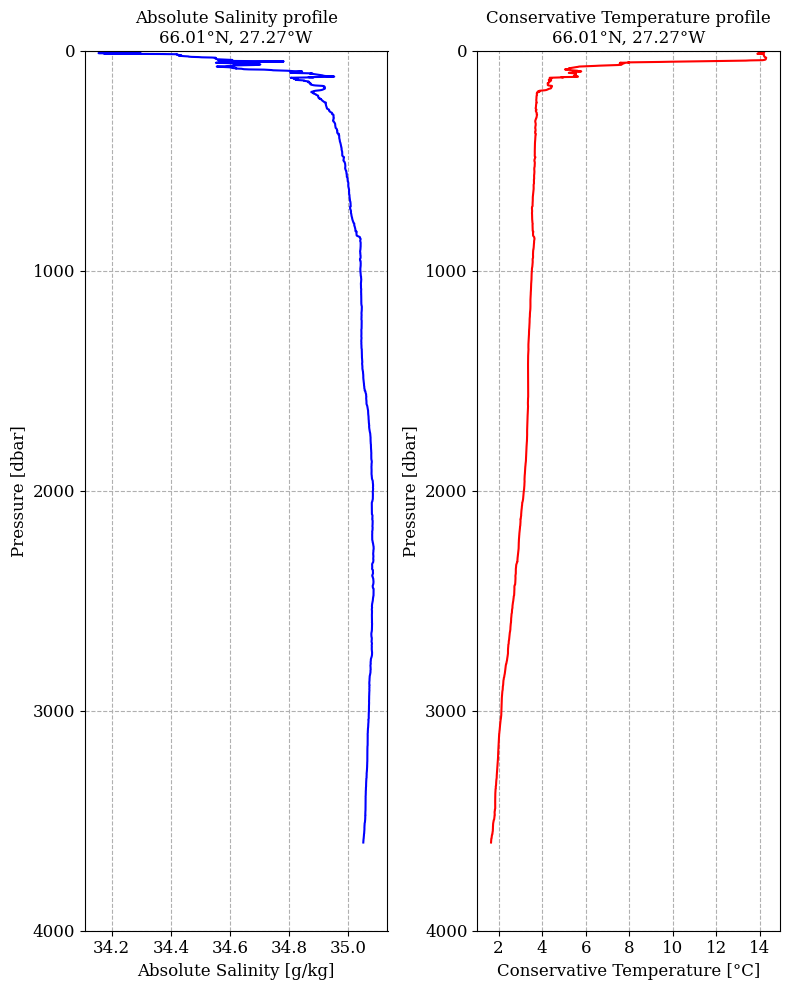

In [31]:
# YOUR CODE HERE
# Plot the absolute salinity and conservative temperature profiles against depth in meters.
# Create a similar two-panel figure to Figure 1, but using the TEOS-10 variables
# Left panel: Absolute salinity vs pressure
# Right panel: Conservative temperature vs pressure
plt.figure(2, figsize=(8, 10))
plt.clf()

# Absolute Salinity profile
plt.subplot(1, 2, 1)
plt.plot(ctd_ds[SA_string], ctd_ds[pres_string], color='blue')
plt.xlabel('Absolute Salinity [g/kg]', fontsize=12)
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.gca().invert_yaxis()
plt.ylim(ctd_ds[pres_string].max(), 0)
plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 4001, 1000), fontsize=12)
plt.title('Absolute Salinity profile\n66.01°N, 27.27°W', fontsize=12)
plt.grid(True, linestyle='--')

# Conservative Temperature profile
plt.subplot(1, 2, 2)
plt.plot(ctd_ds[CT_string], ctd_ds[pres_string], color='red')
plt.xlabel('Conservative Temperature [°C]', fontsize=12)
plt.ylabel('Pressure [dbar]', fontsize=12)
plt.gca().invert_yaxis()
plt.ylim(ctd_ds[pres_string].max(), 0)
plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 4001, 1000), fontsize=12)
plt.title('Conservative Temperature profile\n66.01°N, 27.27°W', fontsize=12)
plt.grid(True, linestyle='--')

plt.tight_layout()

# IMPORTANT: Change YourName to your actual last name
plt.savefig(figdir + 'ex1fig2-Mako-Messfern.png')
plt.show()

In [32]:
# Test that Figure 2 was created correctly
fig2_files = glob.glob(figdir + 'ex1fig2-*-Messfern.png')
assert len(fig2_files) > 0, "Figure 2 (ex1fig2-YourName-Messfern.png) was not created"
for fig_file in fig2_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 2 test passed: {fig2_files[0]}")

✓ Figure 2 test passed: ../figures/ex1fig2-Mako-Messfern.png


### Saving xarray to netCDF file

Since we've manipulated the data, and may want to use the new variables "Absolute salinity" and "Conservative temperature" again later, let's save the new data file.

In [33]:
ctd_ds.to_netcdf(netcdf_file_with_path_edited)

## T-S Diagram

A T-S diagram has salinity on the x-axis and temperature on the y-axis, and contours of density (sigma_0) added.

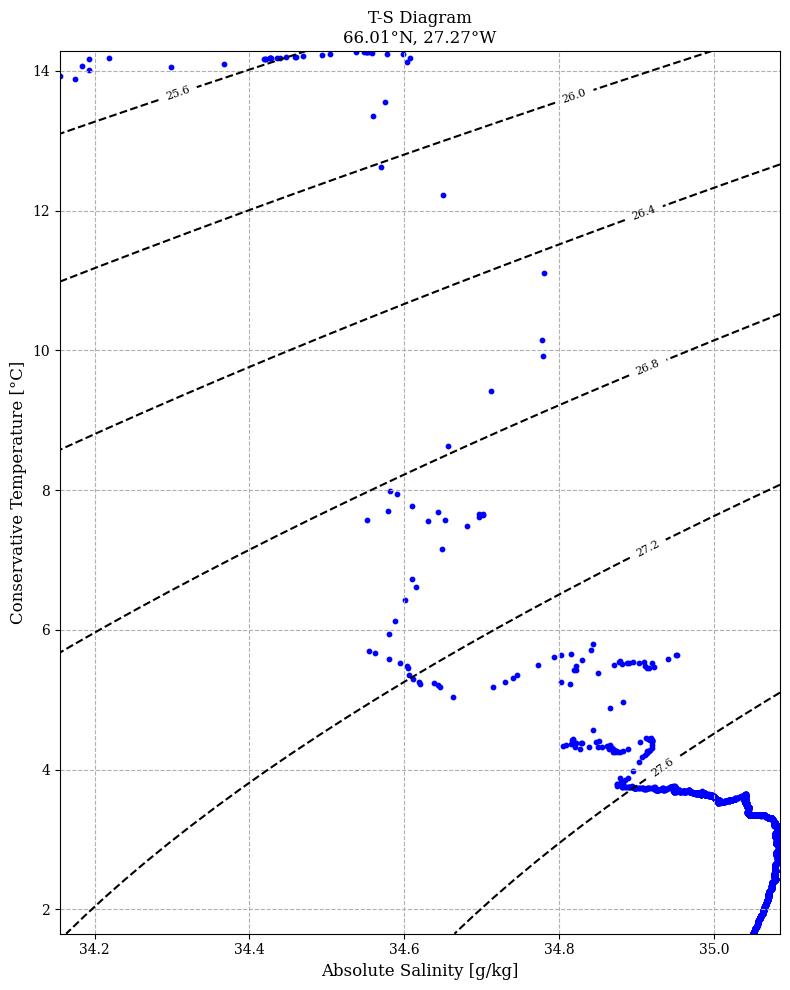

In [35]:
# YOUR CODE HERE
# Follow the original template pattern to create T-S diagram
# Reference: https://stackoverflow.com/questions/41634179/matplotlib-contour-lines-are-not-closing-up

# On a TS diagram, the X axis is salinity and the Y axis is temperature.  
# As a helpful reminder, we can create variables X and Y.
X = ctd_ds[SA_string]
Y = ctd_ds[CT_string]

# A typical TS diagram also has contours of potential density using gsw package.
# Use np.meshgrid and gsw.density.sigma0() to create density contours
# Plot the data points and add contour lines with labels
plt.figure(3, figsize=(8, 10))
plt.clf()

# Plot data points
plt.scatter(X, Y, c='blue', s=10)

# Create grid for density contours
si = np.linspace(float(X.min()), float(X.max()), 50)
ti = np.linspace(float(Y.min()), float(Y.max()), 50)

Si, Ti = np.meshgrid(si, ti)

# Calculate sigma0 density
sigma0 = gsw.density.sigma0(Si, Ti)

# Plot density contours
contours = plt.contour(Si, Ti, sigma0, colors='black', linestyles='--')

# Add contour labels
plt.clabel(contours, inline=True, fontsize=8)

# Labels and title
plt.xlabel('Absolute Salinity [g/kg]', fontsize=12)
plt.ylabel('Conservative Temperature [°C]', fontsize=12)

plt.title('T-S Diagram\n66.01°N, 27.27°W', fontsize=12)

plt.grid(True, linestyle='--')

plt.tight_layout()

# IMPORTANT: Change YourName to your actual last name
plt.savefig(figdir + 'ex1fig3-Mako-Messfern.png')
plt.show()

In [36]:
# Test that Figure 3 was created correctly
fig3_files = glob.glob(figdir + 'ex1fig3-*-Messfern.png')
assert len(fig3_files) > 0, "Figure 3 (ex1fig3-YourName-Messfern.png) was not created"
for fig_file in fig3_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 3 test passed: {fig3_files[0]}")

✓ Figure 3 test passed: ../figures/ex1fig3-Mako-Messfern.png


## Enhanced T-S Diagram (Figure 4)

Repeat the plot here, but with the following enhancements:
- Plot the contours first, then the data points (makes data points more visible)
- Try removing the grid lines
- Change the aspect ratio of the plot to make it square
- Change the color of the line to red
- Change the axes limits to focus on the data denser than 27.00 kg/m³

/tmp/ipykernel_13016/3419895068.py:40: UserWarning: Ignoring specified arguments in this call because figure with num: 4 already exists
  plt.figure(4, figsize=(8, 6))


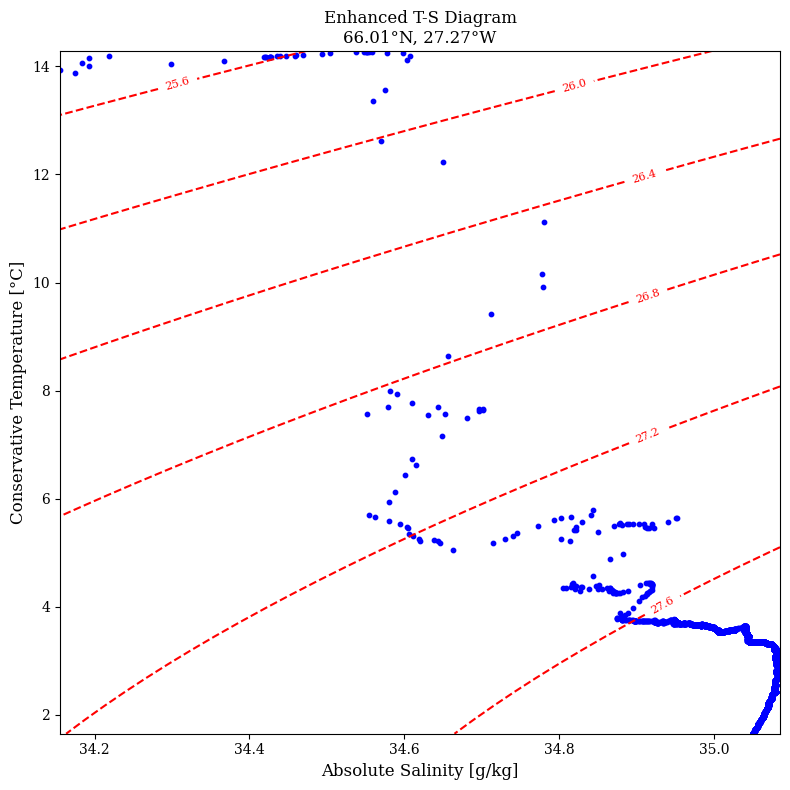

In [39]:
# YOUR CODE HERE
# Repeat the T-S plot from Figure 3, but with these modifications:
# - Plot the contours first, then the data points (makes data points more visible)
# - Remove grid lines
# - Change the aspect ratio of the plot to make it square
# - Change the color of the line to red
# - Change the axes limits to focus on data denser than 27.00 kg/m^3
plt.figure(4, figsize=(8, 8))
plt.clf()

# Create grid for density contours
si = np.linspace(float(X.min()), float(X.max()), 50)
ti = np.linspace(float(Y.min()), float(Y.max()), 50)

Si, Ti = np.meshgrid(si, ti)

# Calculate sigma0 density
sigma0 = gsw.density.sigma0(Si, Ti)

# Plot contours first
contours = plt.contour(
    Si,
    Ti,
    sigma0,
    colors='red',
    linestyles='--'
)

plt.clabel(contours, inline=True, fontsize=8)

# Plot data points afterwards
plt.scatter(X, Y, c='blue', s=10)

# Labels and title
plt.xlabel('Absolute Salinity [g/kg]', fontsize=12)
plt.ylabel('Conservative Temperature [°C]', fontsize=12)

plt.title('Enhanced T-S Diagram\n66.01°N, 27.27°W', fontsize=12)

plt.figure(4, figsize=(8, 6))

# Focus on dense water masses
plt.xlim(float(X.min()), float(X.max()))
plt.ylim(float(Y.min()), float(Y.max()))

plt.tight_layout()

# Save the figure as a .png file in the figures directory
# IMPORTANT: Change YourName to your actual last name
plt.savefig(figdir + 'ex1fig4-Mako-Messfern.png')
plt.show()

In [40]:
# Test that Figure 4 was created correctly
fig4_files = glob.glob(figdir + 'ex1fig4-*-Messfern.png')
assert len(fig4_files) > 0, "Figure 4 (ex1fig4-YourName-Messfern.png) was not created"
for fig_file in fig4_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 4 test passed: {fig4_files[0]}")

✓ Figure 4 test passed: ../figures/ex1fig4-Mako-Messfern.png


## Analysis Questions

**Note:** These questions are for your reflection and will be discussed in class after the assignment deadline. You do not need to submit written answers - they are not part of the automated grading.

**Question 1:** Compare the practical salinity vs. absolute salinity profiles (Figures 1 and 2). What differences do you observe and why are these important for oceanographic analysis?

**Question 2:** Examine your T-S diagrams (Figures 3 and 4). What do the density contours tell you about the water masses in this profile? Which parts of the water column are most/least dense?

**Question 3:** Based on the location of this CTD cast (North Atlantic, 49°42.5'N, 45°00.0'W) and the T-S characteristics you observe, what can you infer about the water masses present? Consider both surface and deep water properties.

**Optional Notes for Class Discussion:**
Feel free to jot down thoughts here, but this section is not graded:

1. [There are only relatively small visual differences, but absolute salinity profile is more physically consistent because it accounts for regional variations in the sewater compositions. Also the conservative Temperature is applied instead of the normal Temperature, as they represent the heat content of seawater more accuratly. Therefore its more professional ]

2. [Your observations for Question 2]

3. [Your observations for Question 3]

## Conclusion

Congratulations! You have successfully completed this comprehensive oceanographic data analysis exercise. You have:

- Converted Sea-Bird CNV data to netCDF format using seasenselib
- Calculated TEOS-10 oceanographic parameters (Absolute Salinity, Conservative Temperature)
- Created professional oceanographic profile plots (Figures 1 & 2)
- Generated Temperature-Salinity diagrams with density contours (Figures 3 & 4)
- Analyzed real research data from the North Atlantic Ocean

This exercise demonstrates the complete workflow used by oceanographers for analyzing CTD data, from raw sensor data to scientific interpretation.

## Grading

**This assignment uses a tiered PASS system:**

✅ **PASS (Basic Requirements):**
- All required files created (NetCDF files, 4 figures)
- All automated tests pass (data valid, figures contain content)
- Personal information completed
- Code executes without errors

🌟 **PASS PLUS (Professional Quality):**
All PASS requirements PLUS:
- Sensible legends and titles on all figures
- Good choices for figure plotting (appropriate aspect ratios, professional color scales, clear line styles)
- All axes have proper labels with units (e.g., "Temperature (°C)", "Pressure (dbar)", "Salinity (g/kg)")
- Thoughtful formatting (readable fonts, appropriate figure sizes)
- Professional T-S diagram styling with proper density contour labels

❌ **FAIL Conditions:**
- Missing required outputs
- Test failures (invalid data, empty figures)
- Code execution errors
- Template placeholders not replaced

**Analysis Questions:** The analysis questions above are for reflection and will be discussed in class after the assignment deadline.